In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from mbt_gym.gym.N_Bek_TradingEnvironment import Bek_TradingEnvironment
from mbt_gym.stochastic_processes.N_arrival_models import (
    SynchronousLOBDepthModel,
    SynchronousHawkesArrivalModel,
)
from mbt_gym.stochastic_processes.N_fill_probability_models import DynamicLOBExponentialFillFunction
from mbt_gym.stochastic_processes.N_midprice_models import BrownianMotionMidpriceModel
from mbt_gym.gym.N_Bek_ModelDynamics import Bek_LimitOrderModelDynamics
from mbt_gym.rewards.N_RewardFunctions import CjMmCriterion
from mbt_gym.agents.Agent import Agent
from mbt_gym.gym.helpers.N_generate_trajectory import generate_trajectory


In [ ]:
# ============================
# === PARAMETER BLOCK (A1) ===
# === Multi-asset style, N=1
# Just Parameter Definition
# ============================

import numpy as np

# --- CONFIG ---
num_assets = 1
num_trajectories = 100_000
terminal_time = 1.0
arrival_rate = 10.0
n_steps = int(10 * terminal_time * arrival_rate)  # = 100
step_size = terminal_time / n_steps
global_seed = 123 # 42

# --- REWARD FUNCTION PARAMETERS ---
phi = 0.01
alpha = 0.1

# --- ARRIVAL MODEL PARAMETERS (single asset bid/ask) ---
baseline_arrival_rate = np.array([12.0, 12.0])
mean_reversion_speed = 15.0
self_jump_size = 3.0
mutual_jump_size = 1.5
synchrony_factor = 0.05
cross_asset_influence = 0.0  # no cross-asset effect when N=1

# --- LOB DEPTH MODEL PARAMETERS (single asset bid/ask) ---
c_baseline_depth = np.array([2.0, 2.0])
c_mean_reversion_speed = 10.0
c_self_jump_size = 0.6
c_mutual_jump_size = 0.3
c_synchrony_factor = 0.05
c_cross_asset_influence = 0.0

# --- MIDPRICE MODEL PARAMETERS ---
mid_drift = 0.0
mid_volatility = 0.1
mid_initial_price = 100.0

# --- FIXED AGENT ACTION ---
fixed_action_value = 0.5


In [2]:

# ============================
# === PARAMETER BLOCK (A2) === for N=2 case
# ============================

import numpy as np

# --- CONFIG ---
num_assets = 2
num_trajectories = 100_000
terminal_time = 1.0
n_steps = 100
step_size = terminal_time / n_steps
global_seed = 123 # 42

# --- REWARD FUNCTION PARAMETERS ---
phi = 0.005     # per-step inventory aversion
alpha = 0.2     # terminal inventory aversion

# --- ARRIVAL MODEL PARAMETERS ---
#baseline_arrival_rate = np.array([[28.0, 28.0],
                                 # [30.0, 30.0]])
baseline_arrival_rate = np.array([[10.0, 10.0],
                                  [12.0, 12.0]])

#mean_reversion_speed = np.array([90.0, 95.0])
mean_reversion_speed = np.array([15.0, 18.0])
#self_jump_size       = np.array([10.0, 11.0])
#mutual_jump_size     = np.array([6.0, 7.0])

self_jump_size       = np.array([3.0, 3.2])
mutual_jump_size     = np.array([1.5, 1.6])

#synchrony_factor     = np.array([0.1, 0.1])
synchrony_factor     = np.array([0.05, 0.05])
#cross_asset_influence = np.array([[0.0, 0.05],
                                  #[0.05, 0.0]])
cross_asset_influence = np.array([[0.0, 3.0],
                                  [3.0, 0.0]])

# --- LOB DEPTH MODEL PARAMETERS ---
c_baseline_depth = np.array([[2.0, 2.0],
                             [2.5, 2.5]])
#c_mean_reversion_speed = np.array([70.0, 75.0])
c_mean_reversion_speed = np.array([10.0, 12.0])
c_self_jump_size       = np.array([0.6, 0.65])
c_mutual_jump_size     = np.array([0.3, 0.32])
#c_synchrony_factor     = np.array([0.05, 0.05])
c_synchrony_factor     = np.array([0.05, 0.05])
#c_cross_asset_influence = np.array([[0.0, 0.05],
                                    #[0.05, 0.0]])

c_cross_asset_influence = np.array([[0.0, 0.0],
                                    [0.0, 0.0]])

# --- MIDPRICE MODEL PARAMETERS ---
mid_drift = 0.0
#mid_volatility = np.array([0.1, 0.15])
mid_volatility = np.array([0.1, 0.1])
mid_initial_price = np.array([100.0, 100.0])

# --- FIXED AGENT ACTION ---
#fixed_action_value = 1.0 # 1.0
fixed_action_value = 0.5


In [3]:
# ============================
# === PARAMETER BLOCK (A3) === for N=3 case
# ============================

import numpy as np

# --- CONFIG ---
num_assets = 3
num_trajectories = 100_000
terminal_time = 1.0
arrival_rate = 10.0
n_steps = int(10 * terminal_time * arrival_rate)   # = 100
step_size = terminal_time / n_steps                # = 0.01
global_seed = 123  # same as train_seed

# --- REWARD FUNCTION PARAMETERS ---
phi = 0.005     # per-step inventory aversion
alpha = 0.2     # terminal inventory aversion

# --- ARRIVAL MODEL PARAMETERS ---
# from your N=3 builder
baseline_arrival_rate = np.array([
    [10.0, 10.0],
    [12.0, 12.0],
    [14.0, 14.0],
])  # shape (3,2)

mean_reversion_speed = np.array([15.0, 18.0, 21.0])
self_jump_size       = np.array([3.0,  3.2,  3.4])
mutual_jump_size     = np.array([1.5,  1.6,  1.7])
synchrony_factor     = np.array([0.05, 0.05, 0.05])

cross_asset_influence = np.array([
    [0.0,  0.05, 0.05],
    [0.05, 0.0,  0.05],
    [0.05, 0.05, 0.0 ],
])  # shape (3,3)

# --- LOB DEPTH MODEL PARAMETERS ---
# from your N=3 builder
c_baseline_depth = np.array([
    [2.0, 2.0],
    [2.5, 2.5],
    [3.0, 3.0],
])  # shape (3,2)

c_mean_reversion_speed = np.array([10.0, 12.0, 14.0])
c_self_jump_size       = np.array([0.6,  0.65, 0.70])
c_mutual_jump_size     = np.array([0.3,  0.32, 0.34])
c_synchrony_factor     = np.array([0.05, 0.05, 0.05])

c_cross_asset_influence = np.array([
    [0.0,  0.05, 0.05],
    [0.05, 0.0,  0.05],
    [0.05, 0.05, 0.0 ],
])  # shape (3,3)

# --- MIDPRICE MODEL PARAMETERS ---
mid_drift = 0.0
mid_volatility = np.array([0.1, 0.1, 0.1])
mid_initial_price = np.array([100.0, 100.0, 100.0])

# --- FIXED AGENT ACTION ---
fixed_action_value = 0.5


STABILITY PRE-CHECK (N=2 case) 

In [4]:
# ============================================================
# Simulation Block B
# Run after A1 Block
# === STABILITY PRE-CHECK (Uses Parameter Block A2 values) 
# Only works with N=2 case
# ============================================================

print("\nRunning stability pre-checks before simulation...")

# ------------------------------------------------------------
# Helper: Build Feedback Matrix M = G + S
# ------------------------------------------------------------

def build_feedback_matrix(mean_rev, self_jump, mutual_jump, cross_asset, synchrony):
    """
    Build combined feedback matrix M = G + S for a multi-asset, 2-side Hawkes-type system.
    Assets: i = 0..A-1
    Sides:  bid=0, ask=1
    """
    A = len(mean_rev)
    dim = 2 * A
    G = np.zeros((dim, dim))
    S = np.zeros((dim, dim))

    def idx(asset, side):  # side: 0=bid, 1=ask
        return 2 * asset + side

    for i in range(A):
        for j in range(A):

            if i == j:
                # Within-asset coupling
                G[idx(i, 0), idx(j, 0)] = self_jump[i]   / mean_rev[i]
                G[idx(i, 1), idx(j, 1)] = self_jump[i]   / mean_rev[i]
                G[idx(i, 0), idx(j, 1)] = mutual_jump[i] / mean_rev[i]
                G[idx(i, 1), idx(j, 0)] = mutual_jump[i] / mean_rev[i]

            else:
                # Cross-asset, same-side excitation
                G[idx(i, 0), idx(j, 0)] = cross_asset[i, j] / mean_rev[i]
                G[idx(i, 1), idx(j, 1)] = cross_asset[i, j] / mean_rev[i]

    # Synchrony within asset (bid↔ask)
    for i in range(A):
        S[idx(i, 0), idx(i, 1)] = synchrony[i]
        S[idx(i, 1), idx(i, 0)] = synchrony[i]

    return G + S


# ------------------------------------------------------------
# Helper: Compute spectral radius
# ------------------------------------------------------------
def spectral_radius(M):
    return float(np.max(np.abs(np.linalg.eigvals(M))))


# ------------------------------------------------------------
# Helper: Run stability check
# ------------------------------------------------------------
def check_stability_block(name, mean_rev, self_jump, mutual_jump, cross_asset, synchrony):
    M = build_feedback_matrix(mean_rev, self_jump, mutual_jump, cross_asset, synchrony)
    rho = spectral_radius(M)

    print(f"\n===== Stability Check: {name} =====")
    print(f"Spectral radius ρ(G+S) = {rho:.4f}  (require ρ < 1 for stability)")

    stable = True

    # Synchrony constraint
    if np.any(np.abs(synchrony) >= 1.0):
        bad = np.where(np.abs(synchrony) >= 1.0)[0]
        print(f"Synchrony ≥ 1.0 for assets {bad + 1}. Reduce synchrony_factor.")
        stable = False

    # Hawkes stability condition
    if rho >= 1.0:
        print("SUPERCRITICAL: feedback > mean reversion. Process may explode.")
        print("Suggestions:")
        print("  • Increase mean_reversion_speed (β or ξ)")
        print("  • Decrease self_jump_size / mutual_jump_size / cross_asset_influence")
        print("  • Reduce synchrony_factor")
        scale = 0.90 / rho
        print(f"  • Try scaling excitation parameters by ≈ {scale:.3f}")
        stable = False
    else:
        print("SUBCRITICAL (stable): mean reversion dominates.")

    return rho, stable


# ------------------------------------------------------------
# RUN STABILITY CHECKS (directly using Block A parameters)
# ------------------------------------------------------------

rho_h, stable_h = check_stability_block(
    "MO Intensities (Hawkes Arrivals)",
    mean_reversion_speed,
    self_jump_size,
    mutual_jump_size,
    cross_asset_influence,
    synchrony_factor,
)

rho_c, stable_c = check_stability_block(
    "LOB Depth Dynamics",
    c_mean_reversion_speed,
    c_self_jump_size,
    c_mutual_jump_size,
    c_cross_asset_influence,
    c_synchrony_factor,
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

if stable_h and stable_c:
    print("\nAll systems stable — ready to proceed to simulation.\n")
else:
    print("\nOne or more systems unstable — adjust parameters above.\n")



Running stability pre-checks before simulation...

===== Stability Check: MO Intensities (Hawkes Arrivals) =====
Spectral radius ρ(G+S) = 0.3504  (require ρ < 1 for stability)
SUBCRITICAL (stable): mean reversion dominates.

===== Stability Check: LOB Depth Dynamics =====
Spectral radius ρ(G+S) = 0.1434  (require ρ < 1 for stability)
SUBCRITICAL (stable): mean reversion dominates.

All systems stable — ready to proceed to simulation.



In [14]:
# NOTE:  This NOT Stability Check
# Computing Average Values (OVER SIMULATIONS) to use in plots like Contor Plots 

# ============================
# === SIMULATION BLOCK (B) ===
# Run after Parameter Block A1 (N=1) or A (e.g., N=2)
# Works with N=1,2,3,...
# ============================

# === Fixed Agent Simulation for Parameter Tuning + Diagnostics ===
# Uses constant actions across a large number of trajectories (e.g., 100,000)
# to estimate:
#   1) baseline inventory-neutral reward
#   2) average MO intensities (bid/ask) per asset
#   3) average LOB depths (bid/ask) per asset
#
# We compute:
#   - mean over trajectories at each time step
#   - then mean over time (with optional burn-in)

import numpy as np

# =================================
# Build stochastic process models
# (NO per-model seeds)
# =================================

arrival_model = SynchronousHawkesArrivalModel(
    step_size=step_size,
    terminal_time=terminal_time,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
    baseline_arrival_rate=baseline_arrival_rate,
    mean_reversion_speed=mean_reversion_speed,
    self_jump_size=self_jump_size,
    mutual_jump_size=mutual_jump_size,
    synchrony_factor=synchrony_factor,
    cross_asset_influence=cross_asset_influence,
)

lob_depth_model = SynchronousLOBDepthModel(
    step_size=step_size,
    terminal_time=terminal_time,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
    c_baseline_depth=c_baseline_depth,
    c_mean_reversion_speed=c_mean_reversion_speed,
    c_self_jump_size=c_self_jump_size,
    c_mutual_jump_size=c_mutual_jump_size,
    c_synchrony_factor=c_synchrony_factor,
    c_cross_asset_influence=c_cross_asset_influence,
)

fill_probability_model = DynamicLOBExponentialFillFunction(
    lob_depth_model=lob_depth_model,
    step_size=step_size,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
)

midprice_model = BrownianMotionMidpriceModel(
    drift=mid_drift,
    volatility=mid_volatility,
    initial_price=mid_initial_price,
    terminal_time=terminal_time,
    step_size=step_size,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
)

model_dynamics = Bek_LimitOrderModelDynamics(
    midprice_model=midprice_model,
    arrival_model=arrival_model,
    fill_probability_model=fill_probability_model,
    lob_depth_model=lob_depth_model,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
)

reward_function = CjMmCriterion(
    per_step_inventory_aversion=phi,
    terminal_inventory_aversion=alpha,
    terminal_time=terminal_time,
    num_assets=num_assets,
)

# Seed only here
env = Bek_TradingEnvironment(
    terminal_time=terminal_time,
    n_steps=n_steps,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
    model_dynamics=model_dynamics,
    reward_function=reward_function,
    normalise_action_space=False,
    normalise_observation_space=False,
    seed=global_seed,   # single source of truth
)

# (Optional but explicit)
#env.seed(global_seed)   # ensures processes get reseeded BEFORE reset

# =================================
# Memory-light simulation + stats
# =================================

obs = env.reset()
T = n_steps

arr_mean_t = np.zeros((T + 1, num_assets, 2))
lob_mean_t = np.zeros((T + 1, num_assets, 2))

episode_rewards = np.zeros(num_trajectories)

arr_mean_t[0] = arrival_model.get_intensities().mean(axis=0)
lob_mean_t[0] = lob_depth_model.get_depths().mean(axis=0)

for t in range(T):
    action = np.ones((num_trajectories, num_assets, 2)) * fixed_action_value

    obs, reward, done, info = env.step(action)

    episode_rewards += np.asarray(reward).reshape(-1)

    arr_mean_t[t + 1] = arrival_model.get_intensities().mean(axis=0)
    lob_mean_t[t + 1] = lob_depth_model.get_depths().mean(axis=0)

    if done[0]:
        break

mean_reward_scalar = episode_rewards.mean()
print(f"Baseline reward (mean over {num_trajectories} trajectories): {mean_reward_scalar:.4f}")

burn_frac = 0.10
burn = int(burn_frac * arr_mean_t.shape[0])

arr_mean = arr_mean_t[burn:].mean(axis=0)
lob_mean = lob_mean_t[burn:].mean(axis=0)

print("\n=== Average MO Intensities (post-burn) ===")
for a in range(num_assets):
    print(f"Asset {a}: bid λ = {arr_mean[a, 0]:.4f}, ask λ = {arr_mean[a, 1]:.4f}")

print("\n=== Average LOB Depths (post-burn) ===")
for a in range(num_assets):
    print(f"Asset {a}: bid c = {lob_mean[a, 0]:.4f}, ask c = {lob_mean[a, 1]:.4f}")

print("\n=== Overall averages (all assets/sides) ===")
print(f"Overall avg λ: {arr_mean.mean():.4f}")
print(f"Overall avg c: {lob_mean.mean():.4f}")


Baseline reward (mean over 100000 trajectories): 3.4859

=== Average MO Intensities (post-burn) ===
Asset 0: bid λ = 21.6324, ask λ = 21.6276
Asset 1: bid λ = 22.4401, ask λ = 22.4369

=== Average LOB Depths (post-burn) ===
Asset 0: bid c = 4.0002, ask c = 3.9998
Asset 1: bid c = 4.4415, ask c = 4.4410

=== Overall averages (all assets/sides) ===
Overall avg λ: 22.0342
Overall avg c: 4.2206


Step 0:
  Asset 0: Depths=[2.00, 2.00], Intensities=[10.00, 10.00], Actions=[0.50, 0.50], Inventory=0.00, FillProb=[0.37, 0.37]
  Asset 1: Depths=[2.50, 2.50], Intensities=[12.00, 12.00], Actions=[0.50, 0.50], Inventory=0.00, FillProb=[0.29, 0.29]
  Reward: 0.00

Step 1:
  Asset 0: Depths=[2.01, 2.01], Intensities=[10.07, 10.07], Actions=[0.50, 0.50], Inventory=0.00, FillProb=[0.37, 0.37]
  Asset 1: Depths=[2.52, 2.52], Intensities=[12.11, 12.11], Actions=[0.50, 0.50], Inventory=0.00, FillProb=[0.28, 0.28]
  Reward: 0.00

Step 2:
  Asset 0: Depths=[2.02, 2.02], Intensities=[10.14, 10.14], Actions=[0.50, 0.50], Inventory=0.00, FillProb=[0.36, 0.36]
  Asset 1: Depths=[2.53, 2.53], Intensities=[12.20, 12.20], Actions=[0.50, 0.50], Inventory=0.00, FillProb=[0.28, 0.28]
  Reward: 0.00

Step 3:
  Asset 0: Depths=[2.08, 2.08], Intensities=[10.24, 10.24], Actions=[0.50, 0.50], Inventory=0.00, FillProb=[0.35, 0.35]
  Asset 1: Depths=[3.51, 3.51], Intensities=[17.07, 17.07], Actions=[0.50, 0.50]

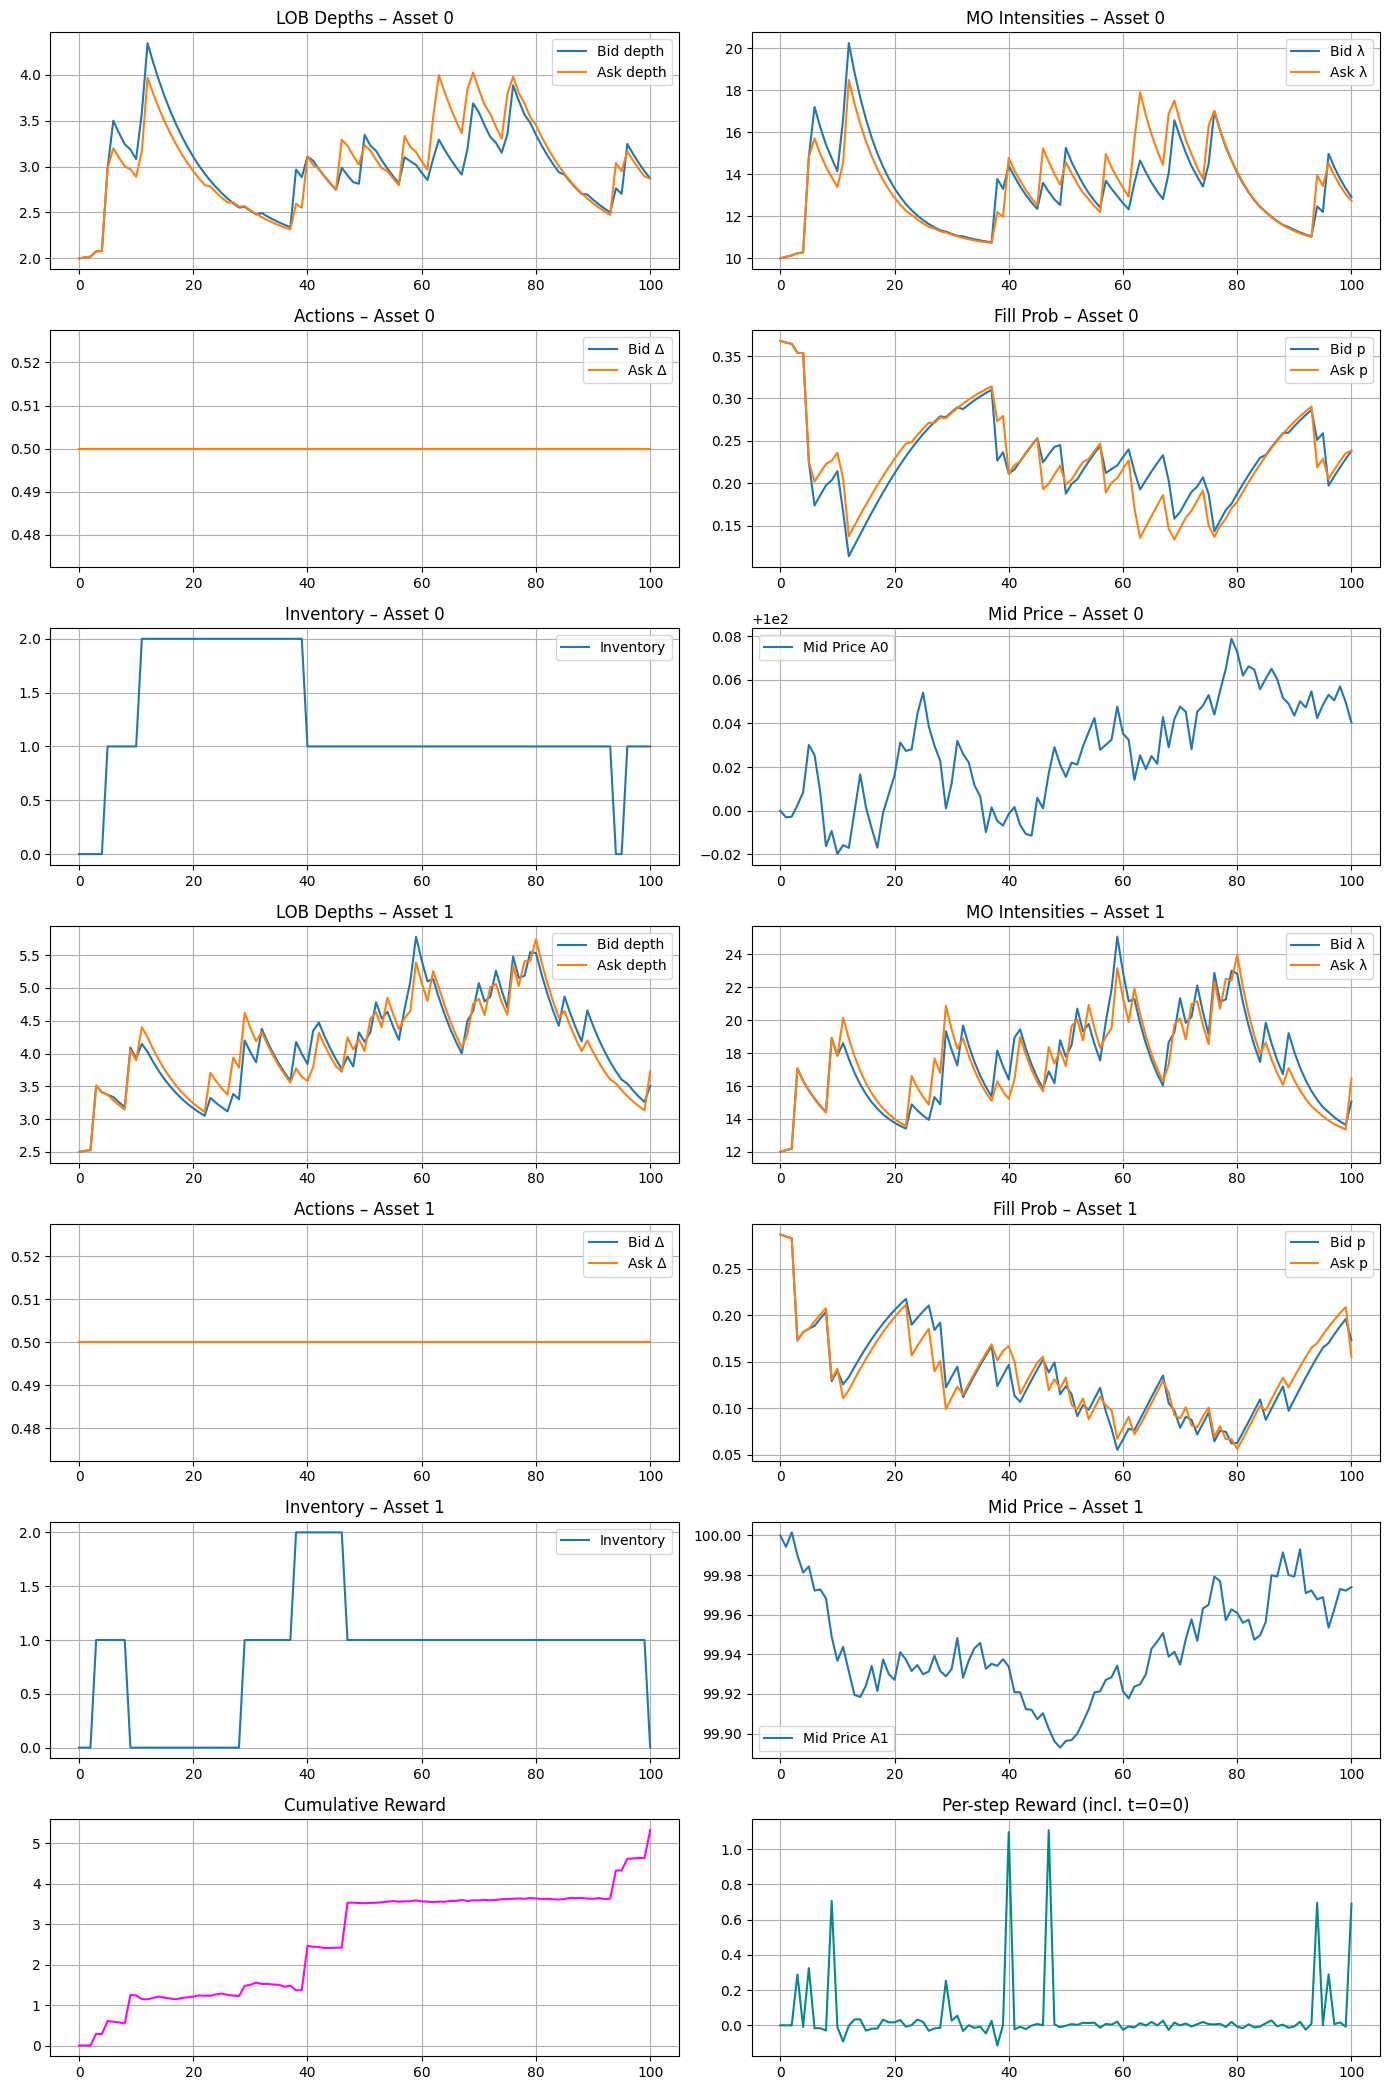

In [6]:
# ============================
# === SIMULATION BLOCK (C) ===
# Must be run after Block A 
# Fixed agent, single (or few) trajectories
# Very Useful for visual analysis of MO/LOB process, fill probabilities etc over time
# ============================

# =================================
# Build stochastic process models
# =================================

arrival_model = SynchronousHawkesArrivalModel(
    step_size=step_size,
    terminal_time=terminal_time,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
    baseline_arrival_rate=baseline_arrival_rate,
    mean_reversion_speed=mean_reversion_speed,
    self_jump_size=self_jump_size,
    mutual_jump_size=mutual_jump_size,
    synchrony_factor=synchrony_factor,
    cross_asset_influence=cross_asset_influence,
)
### print the set of parameters
#print("=== N-VERSION ARRIVAL MODEL PARAMS ===")
#print("baseline_arrival_rate:", arrival_model.baseline_arrival_rate)
#print("mean_reversion_speed:", arrival_model.mean_reversion_speed)
#print("self_jump_size:", arrival_model.self_jump_size)
#print("mutual_jump_size:", arrival_model.mutual_jump_size)
#print("synchrony_factor:", arrival_model.synchrony_factor)
#print("cross_asset_influence:", arrival_model.cross_asset_influence)
#print("step_size:", arrival_model.step_size)


lob_depth_model = SynchronousLOBDepthModel(
    step_size=step_size,
    terminal_time=terminal_time,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
    c_baseline_depth=c_baseline_depth,
    c_mean_reversion_speed=c_mean_reversion_speed,
    c_self_jump_size=c_self_jump_size,
    c_mutual_jump_size=c_mutual_jump_size,
    c_synchrony_factor=c_synchrony_factor,
    c_cross_asset_influence=c_cross_asset_influence,
)

fill_probability_model = DynamicLOBExponentialFillFunction(
    lob_depth_model=lob_depth_model,
    step_size=step_size,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
)

midprice_model = BrownianMotionMidpriceModel(
    drift=mid_drift,
    volatility=mid_volatility,
    initial_price=mid_initial_price,
    terminal_time=terminal_time,
    step_size=step_size,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
)

model_dynamics = Bek_LimitOrderModelDynamics(
    midprice_model=midprice_model,
    arrival_model=arrival_model,
    fill_probability_model=fill_probability_model,
    lob_depth_model=lob_depth_model,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
)

reward_function = CjMmCriterion(
    per_step_inventory_aversion=phi,
    terminal_inventory_aversion=alpha,
    terminal_time=terminal_time,
    num_assets=num_assets,
)

env = Bek_TradingEnvironment(
    terminal_time=terminal_time,
    n_steps=n_steps,
    num_trajectories=num_trajectories,
    num_assets=num_assets,
    model_dynamics=model_dynamics,
    reward_function=reward_function,
    normalise_action_space=False,
    normalise_observation_space=False,
    initial_inventory=np.zeros(num_assets),
    seed=global_seed,  # single source of truth
)

# =================================
# Monitoring arrays
# =================================

lob_depths_bid = [[] for _ in range(num_assets)]
lob_depths_ask = [[] for _ in range(num_assets)]
mo_intensities_bid = [[] for _ in range(num_assets)]
mo_intensities_ask = [[] for _ in range(num_assets)]
actions_bid = [[] for _ in range(num_assets)]
actions_ask = [[] for _ in range(num_assets)]
inventory_over_time = [[] for _ in range(num_assets)]
fill_probs_bid = [[] for _ in range(num_assets)]
fill_probs_ask = [[] for _ in range(num_assets)]
mid_prices = [[] for _ in range(num_assets)]
rewards = []  # will include t=0 reward = 0.0

# =================================
# Run simulation
# =================================

obs = env.reset()

# ---------- t = 0 snapshot (before any env.step) ----------

# Use the same constant action as in the loop
initial_action = np.ones((num_trajectories, num_assets, 2)) * fixed_action_value
initial_depths = model_dynamics._limit_depths(initial_action)
initial_fill_probs = model_dynamics.fill_probability_model._get_fill_probabilities(initial_depths)
initial_inventory = model_dynamics.state[:, 1:1 + num_assets][0]
initial_lob_depths = lob_depth_model.get_depths()[0]
initial_intensities = arrival_model.get_intensities()[0]
initial_mids = midprice_model.current_state[0, :, 0]

# Store t=0 paths (first trajectory)
for i in range(num_assets):
    lob_depths_bid[i].append(initial_lob_depths[i, 0])
    lob_depths_ask[i].append(initial_lob_depths[i, 1])
    mo_intensities_bid[i].append(initial_intensities[i, 0])
    mo_intensities_ask[i].append(initial_intensities[i, 1])
    actions_bid[i].append(initial_depths[0, i, 0])
    actions_ask[i].append(initial_depths[0, i, 1])
    inventory_over_time[i].append(initial_inventory[i])
    fill_probs_bid[i].append(initial_fill_probs[0, i, 0])
    fill_probs_ask[i].append(initial_fill_probs[0, i, 1])
    mid_prices[i].append(initial_mids[i])

# No reward has been earned yet at t=0
rewards.append(0.0)

# Optional: print t = 0 state so it lines up with the original version
print("Step 0:")
for i in range(num_assets):
    print(
        f"  Asset {i}: "
        f"Depths=[{initial_lob_depths[i, 0]:.2f}, {initial_lob_depths[i, 1]:.2f}], "
        f"Intensities=[{initial_intensities[i, 0]:.2f}, {initial_intensities[i, 1]:.2f}], "
        f"Actions=[{initial_depths[0, i, 0]:.2f}, {initial_depths[0, i, 1]:.2f}], "
        f"Inventory={initial_inventory[i]:.2f}, "
        f"FillProb=[{initial_fill_probs[0, i, 0]:.2f}, {initial_fill_probs[0, i, 1]:.2f}]"
    )
print("  Reward: 0.00\n")

# ---------- main loop (t = 1,2,...,n_steps) ----------

for step in range(n_steps):

    action = np.ones((num_trajectories, num_assets, 2)) * fixed_action_value
    depths = model_dynamics._limit_depths(action)
    obs, reward, done, info = env.step(depths)

    # store reward for first trajectory
    rewards.append(float(reward[0]))

    fill_probs = model_dynamics.fill_probability_model._get_fill_probabilities(depths)
    inventory = model_dynamics.state[:, 1:1 + num_assets][0]
    lob_depths = lob_depth_model.get_depths()[0]
    intensities = arrival_model.get_intensities()[0]
    mids = midprice_model.current_state[0, :, 0]

    # Store paths
    for i in range(num_assets):
        lob_depths_bid[i].append(lob_depths[i, 0])
        lob_depths_ask[i].append(lob_depths[i, 1])
        mo_intensities_bid[i].append(intensities[i, 0])
        mo_intensities_ask[i].append(intensities[i, 1])
        actions_bid[i].append(depths[0, i, 0])
        actions_ask[i].append(depths[0, i, 1])
        inventory_over_time[i].append(inventory[i])
        fill_probs_bid[i].append(fill_probs[0, i, 0])
        fill_probs_ask[i].append(fill_probs[0, i, 1])
        mid_prices[i].append(mids[i])

    # ==============================
    # PRINT FIRST 10 STEPS ONLY
    # (these are now t=1,...,10)
    # ==============================
    if step < 10:
        print(f"Step {step + 1}:")
        for i in range(num_assets):
            print(
                f"  Asset {i}: "
                f"Depths=[{lob_depths[i, 0]:.2f}, {lob_depths[i, 1]:.2f}], "
                f"Intensities=[{intensities[i, 0]:.2f}, {intensities[i, 1]:.2f}], "
                f"Actions=[{depths[0, i, 0]:.2f}, {depths[0, i, 1]:.2f}], "
                f"Inventory={inventory[i]:.2f}, "
                f"FillProb=[{fill_probs[0, i, 0]:.2f}, {fill_probs[0, i, 1]:.2f}]"
            )
        print(f"  Reward: {reward[0]:.2f}\n")

    if done[0]:
        break

# =================================
# Summary
# =================================

total_reward = np.sum(rewards)
print("\n============================")
print(f"Episode length: {len(rewards) - 1} steps")  # subtract t=0
print(f"Total CjMm reward: {total_reward:.6f}")
print("============================\n")

# =================================
# PLOTTING (2 column grid)
# =================================

time_axis = np.arange(len(rewards))  # now includes t=0, so 0..n_steps

plots_per_asset = 6     # now includes mid-prices!
global_plots = 2        # cumulative + per-step reward
total_plots = num_assets * plots_per_asset + global_plots

cols = 2
rows = int(np.ceil(total_plots / cols))

fig, axs = plt.subplots(rows, cols, figsize=(14, 3 * rows))
axs = axs.ravel()

k = 0

for a in range(num_assets):

    # Depths
    ax = axs[k]; k += 1
    ax.plot(time_axis, lob_depths_bid[a], label="Bid depth")
    ax.plot(time_axis, lob_depths_ask[a], label="Ask depth")
    ax.set_title(f"LOB Depths – Asset {a}")
    ax.grid(True); ax.legend()

    # Intensities
    ax = axs[k]; k += 1
    ax.plot(time_axis, mo_intensities_bid[a], label="Bid λ")
    ax.plot(time_axis, mo_intensities_ask[a], label="Ask λ")
    ax.set_title(f"MO Intensities – Asset {a}")
    ax.grid(True); ax.legend()

    # Actions
    ax = axs[k]; k += 1
    ax.plot(time_axis, actions_bid[a], label="Bid Δ")
    ax.plot(time_axis, actions_ask[a], label="Ask Δ")
    ax.set_title(f"Actions – Asset {a}")
    ax.grid(True); ax.legend()

    # Fill probabilities
    ax = axs[k]; k += 1
    ax.plot(time_axis, fill_probs_bid[a], label="Bid p")
    ax.plot(time_axis, fill_probs_ask[a], label="Ask p")
    ax.set_title(f"Fill Prob – Asset {a}")
    ax.grid(True); ax.legend()

    # Inventory
    ax = axs[k]; k += 1
    ax.plot(time_axis, inventory_over_time[a], label="Inventory")
    ax.set_title(f"Inventory – Asset {a}")
    ax.grid(True); ax.legend()

    # MID PRICES
    ax = axs[k]; k += 1
    ax.plot(time_axis, mid_prices[a], label=f"Mid Price A{a}")
    ax.set_title(f"Mid Price – Asset {a}")
    ax.grid(True); ax.legend()

# === GLOBAL PLOTS ===

ax = axs[k]; k += 1
ax.plot(time_axis, np.cumsum(rewards), color='magenta')
ax.set_title("Cumulative Reward")
ax.grid(True)

ax = axs[k]; k += 1
ax.plot(time_axis, rewards, color='darkcyan')
ax.set_title("Per-step Reward (incl. t=0=0)")
ax.grid(True)

# Turn off unused axes
for j in range(k, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()
